# Функция потерь. Практика

## Цели практической работы

- Узнать новые виды функции потерь
- Потренироваться в расчетах функции потерь
- Познакомиться с функционалом библиотеки Scikit-learn

## Что входит в практическую работу

- Загрузить данные и ознакомиться с ними
- Изучить формулы для новых функций потерь
- Реализовать расчет с помощью стандартных средств python
- Реализовать расчет с помощью  библиотеки Scikit-learn

## Что оценивается 

- Программа выдаёт верный ответ на заданном наборе данных

Откройте Jupyter Notebook и выполните задачи.
Задание не нужно сдавать на проверку.

## Задача

Пусть у нас имеется некоторый набор данных, где `y` - это правильные ответы, а `y_pred` - ответы, предсказанные моделью.

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [19]:
np.random.seed(0) # для воспроизведения результатов
x = np.random.rand(100, 1)
y = 1 + 5 * x + np.random.randn(100, 1)
y_pred = 1 + 5 * x

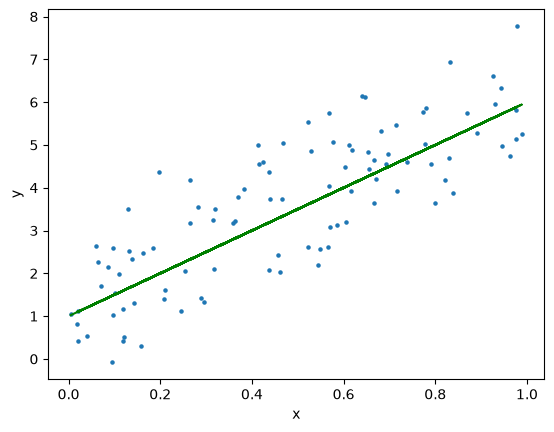

In [20]:
# plot
plt.scatter(x, y, s=5)
plt.plot(x, y_pred, 'g')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

На уроке вы рассмотрели для задачи регрессии функцию потерь `MAE`, ваша задача для этого же примера рассмотреть `MSE` и `RMSE`. 

### 1. Определите ошибку MSE для этих данных

1. Реализуйте функцию самостоятельно с помощью стандартных средств Python.


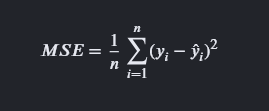

In [21]:
# Наша кастомная функция
def mean_squared_error_custom(y_true, y_pred):
    return sum((true - pred) ** 2 for true, pred in zip(y_true, y_pred)) / len(y_true)

# Считаем обеими функциями на одних и тех же данных
print(f'MSE (кастомная): {mean_squared_error_custom(y, y_pred)}')

MSE (кастомная): [1.02976172]


2. Подключите необходимый функционал из `sklearn`. Реализуйте эту же функцию с помощью библиотеки.

In [22]:
# Ваш код здесь
from sklearn.metrics import mean_squared_error

In [23]:
print(f'MSE: {mean_squared_error(y, y_pred)}')

MSE: 1.0297617241074741


### 2. Определите ошибку RMSE для этих данных

1. Реализуйте функцию самостоятельно с помощью стандартных средств Python.

In [25]:
# Ваш код здесь
import math
print(f'RMSE: {math.sqrt(mean_squared_error(y, y_pred))}')

RMSE: 1.0147717596127093


2. Подключите необходимый функционал из `sklearn`. Реализуйте эту же функцию с помощью библиотеки.

In [26]:
# Ваш код здесь
# Способ через прямую функцию из sklearn
from sklearn.metrics import root_mean_squared_error

print(f'RMSE: {root_mean_squared_error(y, y_pred)}')


RMSE: 1.0147717596127093


### 3. Еще один пример

Пусть имеется набор точек

In [27]:
x_ex2 = np.array([1, 2, 3, 4])
y_ex2 = np.array([1, 2, 3, 10])

и следующие модельные оценки

In [28]:
y_pred1 = np.array([1, 3, 5, 7])
y_pred2 = np.array([3, 4, 5, 6])
y_pred3 = np.array([1, 2, 3, 4])

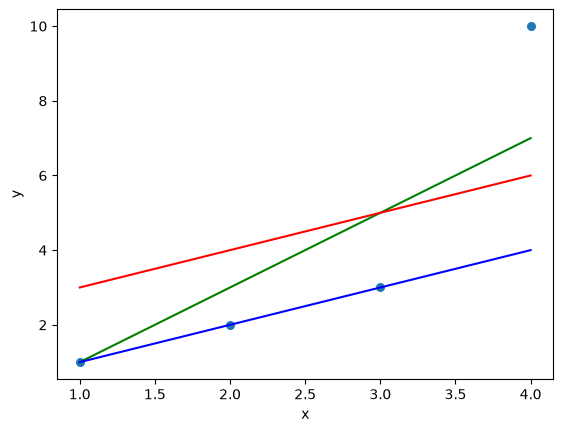

In [29]:
# plot
plt.scatter(x_ex2, y_ex2, s=30)
plt.plot(x_ex2, y_pred1, 'g')
plt.plot(x_ex2, y_pred2, 'r')
plt.plot(x_ex2, y_pred3, 'b')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Сравните значения ошибок MAE, MSE, RMSE для следующего примера

In [30]:
mean_squared_error(y_ex2, y_pred1)

3.5

|

|

|

|

|

|

|

|

|

|

|

## Ответы для самостоятельной проверки

### 1. MSE

In [ ]:
sum((y-y_pred)**2)/len(y)

array([1.02976172])

In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y,y_pred)

1.0297617241074741

### 2. RMSE

In [ ]:
mse = sum((y-y_pred)**2)/len(y)
np.sqrt(mse)

array([1.01477176])

In [ ]:
np.sqrt(mean_squared_error(y, y_pred))

1.0147717596127093

### 3. Пример

In [ ]:
from sklearn.metrics import mean_absolute_error

print('MAE для y_pred1:', mean_absolute_error(y_ex2, y_pred1))
print('MAE для y_pred2:', mean_absolute_error(y_ex2, y_pred2))
print('MAE для y_pred3:', mean_absolute_error(y_ex2, y_pred3))

MAE для y_pred1: 1.5
MAE для y_pred2: 2.5
MAE для y_pred3: 1.5


In [ ]:
print('MSE для y_pred1:', mean_squared_error(y_ex2, y_pred1))
print('MSE для y_pred2:', mean_squared_error(y_ex2, y_pred2))
print('MSE для y_pred3:', mean_squared_error(y_ex2, y_pred3))

MSE для y_pred1: 3.5
MSE для y_pred2: 7.0
MSE для y_pred3: 9.0


In [ ]:
print('RMSE для y_pred1:', np.sqrt(mean_squared_error(y_ex2, y_pred1)))
print('RMSE для y_pred2:', np.sqrt(mean_squared_error(y_ex2, y_pred2)))
print('RMSE для y_pred3:', np.sqrt(mean_squared_error(y_ex2, y_pred3)))

RMSE для y_pred1: 1.8708286933869707
RMSE для y_pred2: 2.6457513110645907
RMSE для y_pred3: 3.0


Таким образом, наблюдаем, что для ситуации 4-й точки `x=4, y=10`, которая не лежит на прямой с остальными точками:
- ошибки MSE и RMSE принимают значения для `y_pred3` выше, чем `y_pred1`
- ошибка MAE  для `y_pred3` и `y_pred1` одинакова.

Будьте внимательны далее при использовании метрик!